In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../clean_data/struct_panel.csv')
df['date'] = pd.to_datetime(df["date"])

In [3]:
def stats_panel(
    df,
    freq="W",                 # "W" = semaine, "M" = mois, etc.
    min_obs=5,                # minimum de messages par période
    indiv_col="user",
    date_col="date",
    special_col="user_political"    # colonne binaire indiquant les obs spéciales
):
    """
    Calcule :
    - le nombre d'individus conservés
    - le nombre total de points de données conservés
    - le nombre d'observations spéciales restantes

    après agrégation temporelle et filtre sur un minimum
    d'observations par individu/période.
    """

    # Copie pour éviter de modifier le df original
    data = df.copy()

    # Création de la période temporelle
    data["period"] = data[date_col].dt.to_period(freq)

    # Nombre d'observations par individu et période
    counts = (
        data
        .groupby([indiv_col, "period"])
        .size()
        .reset_index(name="n_obs")
    )

    # Garder seulement les périodes avec assez d'observations
    valid_periods = counts[counts["n_obs"] >= min_obs]

    # Fusion pour récupérer les lignes valides
    filtered = data.merge(
        valid_periods[[indiv_col, "period"]],
        on=[indiv_col, "period"],
        how="inner"
    )

    # =========================
    # Statistiques finales
    # =========================

    # Nombre d'individus
    n_indiv = filtered[indiv_col].nunique()

    # Nombre total de points
    n_points = len(filtered)

    # Nombre de périodes individu conservées
    n_periods = (
        filtered[[indiv_col, "period"]]
        .drop_duplicates()
        .shape[0]
    )

    # Nombre d'observations spéciales restantes
    n_special = filtered[special_col].sum()

    # Proportion d'observations spéciales
    special_share = filtered[special_col].mean()

    return {
        "freq": freq,
        "min_obs": min_obs,
        "n_indiv": n_indiv,
        "n_points": n_points,
        "n_indiv_periods": n_periods,
        "n_special": int(n_special),
        "special_share": special_share
    }

In [4]:
len(df['user'].unique()), len(df)

(1276, 529303)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Fréquences testées
freq_labels = [
    "1D",   # jour
    "3D",   # 3 jours
    "W",   # semaine
    "2W",   # 2 semaines
    "M",   # mois
    "3M"    # trimestre glissant
]

# Seuils minimum d'observations
min_obs_values = [1, 3, 5, 8, 9, 10, 12, 15, 20]


# ============================================================
# Calcul matrice heatmap
# ============================================================

heatmap1 = np.zeros((len(min_obs_values), len(freq_labels)))
heatmap2 = np.zeros((len(min_obs_values), len(freq_labels)))
heatmap3 = np.zeros((len(min_obs_values), len(freq_labels)))

for i, min_obs in enumerate(min_obs_values):
    for j, freq_label in enumerate(freq_labels):

        x = stats_panel(df, freq=freq_label, min_obs=min_obs)
        n_points = x['n_points']
        n_points_polt = x['n_special']
        n_users = x['n_indiv']

        heatmap1[i, j] = n_points
        heatmap2[i, j] = n_points_polt
        heatmap3[i, j] = n_users

C:\Users\cfrou\AppData\Local\Temp\ipykernel_33128\1806282647.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["period"] = data[date_col].dt.to_period(freq)
C:\Users\cfrou\AppData\Local\Temp\ipykernel_33128\1806282647.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["period"] = data[date_col].dt.to_period(freq)
C:\Users\cfrou\AppData\Local\Temp\ipykernel_33128\1806282647.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["period"] = data[date_col].dt.to_period(freq)
C:\Users\cfrou\AppData\Local\Temp\ipykernel_33128\1806282647.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["period"] = data[date_col].dt.to_period(freq)
C:\Users\cfrou\AppData\Local\Temp\ipykernel_33128\1806282647.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone i

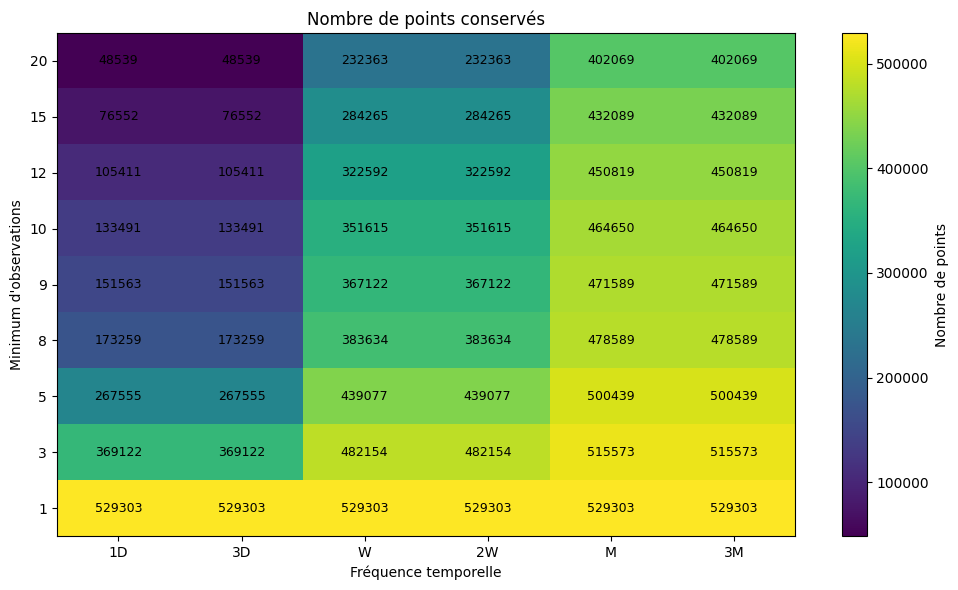

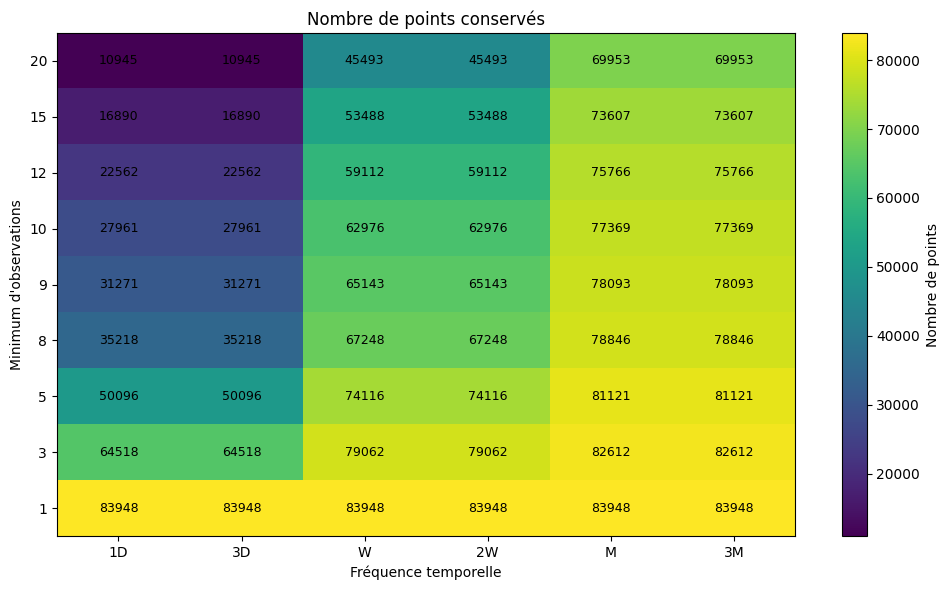

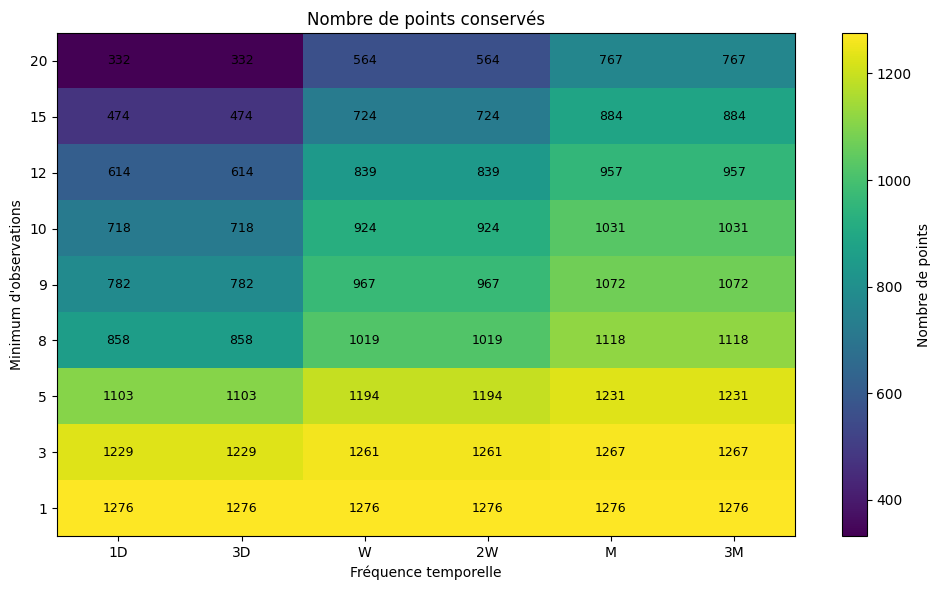

In [7]:
for heatmap in [heatmap1, heatmap2, heatmap3]:
    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        heatmap,
        aspect="auto",
        origin="lower"
    )

    # Axes
    ax.set_xticks(range(len(freq_labels)))
    ax.set_xticklabels(freq_labels)

    ax.set_yticks(range(len(min_obs_values)))
    ax.set_yticklabels(min_obs_values)

    ax.set_xlabel("Fréquence temporelle")
    ax.set_ylabel("Minimum d'observations")
    ax.set_title("Nombre de points conservés")

    # Affichage des valeurs dans les cases
    for i in range(len(min_obs_values)):
        for j in range(len(freq_labels)):
            ax.text(
                j,
                i,
                int(heatmap[i, j]),
                ha="center",
                va="center",
                fontsize=9
            )

    # Barre de couleur
    cbar = plt.colorbar(im)
    cbar.set_label("Nombre de points")

    plt.tight_layout()
    plt.show()